# Figure 4 — Cross-dataset generalization

This notebook generates **Figure 4** of the paper:
- Each optimal n-plet (identified from one dataset) is evaluated on the **other** dataset.
- Violin plots of $\Omega$ across conditions on the target dataset.
- PR-AUC summary table (Table 1) for cross-dataset discrimination.

**Optimal n-plets** (identified via `R1_A_lopo.ipynb`):

| Source | Polarity | n-plet |
|--------|----------|--------|
| MA | $\Omega_C > \Omega_{NR}$ | `[7, 14, 23, 26, 35, 55, 67]` |
| MA | $\Omega_{NR} > \Omega_C$ | `[38, 40, 45, 81]` |
| DBS | $\Omega_C > \Omega_{NR}$ | `[6, 8, 12, 18, 20, 22, 59, 61, 63]` |
| DBS | $\Omega_{NR} > \Omega_C$ | `[3, 4, 10]` |

**Supplementary** `S4_combined_dataset.ipynb` covers the same n-plets evaluated on the
combined MA + DBS dataset.

In [32]:
from pathlib import Path
import os

def ensure_project_root(target_name: str = "high-order-anesthesia") -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name == target_name:
        return cwd
    for parent in cwd.parents:
        if parent.name == target_name:
            os.chdir(parent)
            return parent
    raise RuntimeError(f"Could not find '{target_name}' in path.")

ROOT = ensure_project_root()
print(f"Now in: {ROOT.name}")

Now in: high-order-anesthesia


In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.metrics import average_precision_score, roc_auc_score
from thoi.measures.gaussian_copula import nplets_measures

In [34]:
from src.hoi_anesthesia.io import load_covariance_dict

## Configuration

In [35]:
results_path = "results"
data_path    = "data"
device       = "cuda" if torch.cuda.is_available() else "cpu"
FONTSIZE     = 14
plt.rcParams.update({"font.size": FONTSIZE})

all_covs = load_covariance_dict(f"{data_path}/covariance_matrices_gc.h5")

# ── Optimal n-plets: keys = (source_dataset, polarity) ───────────────────────
optimal_nplets = {
    ("MA",  "c_gt_nr"): [7, 14, 23, 26, 35, 55, 67],
    ("MA",  "nr_gt_c"): [38, 40, 45, 81],
    ("DBS", "c_gt_nr"): [6, 8, 12, 18, 20, 22, 59, 61, 63],
    ("DBS", "nr_gt_c"): [3, 4, 10],
}

conscious_states = {
    "MA":  ["MA_awake"],
    "DBS": ["DBS_awake", "ts_on_5V"],
}
nonresponsive_states = {
    "MA":  ["deep_propofol", "ketamine", "moderate_propofol", "ts_selv2", "ts_selv4"],
    "DBS": ["ts_off", "ts_on_3V_control", "ts_on_5V_control"],
}

pretty_labels = {
    "MA_awake":           "Awake",
    "ts_selv2":           "2% Sevo",
    "ts_selv4":           "4% Sevo",
    "deep_propofol":      "Deep Ppfl",
    "moderate_propofol":  "Light Ppfl",
    "ketamine":           "Ketamine",
    "DBS_awake":          "Awake",
    "ts_on_5V":           "CT high",
    "ts_off":             "off",
    "ts_on_3V_control":   "VT low",
    "ts_on_5V_control":   "VT high",
    "ts_on_3V":           "CT low",
}
custom_order = {
    "MA":  ["MA_awake", "ts_selv2", "ts_selv4", "moderate_propofol", "deep_propofol", "ketamine"],
    "DBS": ["DBS_awake", "ts_on_5V", "ts_on_3V", "ts_on_5V_control", "ts_on_3V_control", "ts_off"],
}
state_colors = {
    "MA_awake":          "#FF9900",
    "ts_selv2":          "#75EACC",
    "ts_selv4":          "#00A073",
    "moderate_propofol": "#CEB8F2",
    "deep_propofol":     "#9C7AD8",
    "ketamine":          "#B0B900",
    "DBS_awake":         "#FF9900",
    "ts_on_5V":          "#FFD166",
    "ts_off":            "#9C7AD8",
    "ts_on_3V_control":  "#109121",
    "ts_on_5V_control":  "#109121",
    "ts_on_3V":          "#757575",
}

## Helper utilities

In [36]:
def compute_omega_for_states(nplet, dataset, states_dict):
    """Compute Omega for an n-plet across all scans in states_dict[dataset].
    Returns list of dicts with state, subject, O."""
    records = []
    for state, cov_array in all_covs[dataset].items():
        if state not in [s for sl in states_dict.values() for s in sl]:
            if state not in custom_order.get(dataset, []):
                continue
        cov_t    = torch.as_tensor(cov_array)          # (n_subj, N, N)
        measures = nplets_measures(
            cov_t,
            nplets=[nplet],
            covmat_precomputed=True,
        )
        for subj in range(measures.shape[1]):
            records.append({
                "state":   state,
                "subject": subj,
                "O":       measures[0, subj, 2].item(),
            })
    return records

def compute_prauc(nplet, dataset):
    """Compute PR-AUC, inverted PR-AUC (using -Omega as score) for an n-plet."""
    X, y = [], []
    for state in conscious_states[dataset]:
        for cov in all_covs[dataset][state]:
            cov_t    = torch.as_tensor(cov).unsqueeze(0)
            measures = nplets_measures(cov_t, nplets=[nplet], covmat_precomputed=True)
            X.append(measures[0, 0, 2].item()); y.append(1)
    for state in nonresponsive_states[dataset]:
        for cov in all_covs[dataset][state]:
            cov_t    = torch.as_tensor(cov).unsqueeze(0)
            measures = nplets_measures(cov_t, nplets=[nplet], covmat_precomputed=True)
            X.append(measures[0, 0, 2].item()); y.append(0)
    X, y = np.array(X), np.array(y)
    try:   pr_auc     = average_precision_score(y,  X)
    except: pr_auc    = np.nan
    try:   pr_auc_inv = average_precision_score(y, -X)
    except: pr_auc_inv = np.nan
    return pr_auc, pr_auc_inv

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def bonferroni(p_dict):
    m = len(p_dict)
    return {s: min(p * m, 1.0) for s, p in p_dict.items()}

def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=FONTSIZE - 2)


---
## Step 1 — Cross-dataset PR-AUC (Table 1)

Each n-plet is evaluated on the **opposite** dataset (cross) and on the **same** dataset
(within, for reference).

In [37]:
rows_prauc = []

for (src_ds, polarity), nplet in optimal_nplets.items():
    tgt_ds = "DBS" if src_ds == "MA" else "MA"
    polarity_label = (r"$\Omega_C > \Omega_{NR}$" if polarity == "c_gt_nr"
                      else r"$\Omega_{NR} > \Omega_C$")

    # within
    pr_w, pr_w_inv = compute_prauc(nplet, src_ds)
    # cross
    pr_x, pr_x_inv = compute_prauc(nplet, tgt_ds)

    rows_prauc.append({
        "src_dataset":       src_ds,
        "polarity":          polarity,
        "polarity_label":    polarity_label,
        "nplet":             nplet,
        "n":                 len(nplet),
        "within_PR_AUC":     round(pr_w,     3),
        "cross_PR_AUC":      round(pr_x,     3),
        "within_PR_AUC_inv": round(pr_w_inv, 3),
        "cross_PR_AUC_inv":  round(pr_x_inv, 3),
        "cross_dataset":     tgt_ds,
    })
    print(f"{src_ds} {polarity}: within PR={pr_w:.3f}  cross({tgt_ds}) PR={pr_x:.3f}  "
          f"within PR_inv={pr_w_inv:.3f}  cross PR_inv={pr_x_inv:.3f}")

prauc_df = pd.DataFrame(rows_prauc)
display(prauc_df[["src_dataset", "polarity_label", "n", "nplet",
                   "within_PR_AUC", "cross_PR_AUC",
                   "within_PR_AUC_inv", "cross_PR_AUC_inv"]])


MA c_gt_nr: within PR=0.997  cross(DBS) PR=0.915  within PR_inv=0.113  cross PR_inv=0.342


MA nr_gt_c: within PR=0.113  cross(DBS) PR=0.832  within PR_inv=0.972  cross PR_inv=0.342


DBS c_gt_nr: within PR=0.970  cross(MA) PR=0.212  within PR_inv=0.305  cross PR_inv=0.310


DBS nr_gt_c: within PR=0.506  cross(MA) PR=0.312  within PR_inv=0.725  cross PR_inv=0.203


,src_dataset,polarity_label,n,nplet,within_PR_AUC,cross_PR_AUC,within_PR_AUC_inv,cross_PR_AUC_inv
0,MA,$\Omega_C > \Omega_{NR}$,7,"[7, 14, 23, 26, 35, 55, 67]",0.997,0.915,0.113,0.342
1,MA,$\Omega_{NR} > \Omega_C$,4,"[38, 40, 45, 81]",0.113,0.832,0.972,0.342
2,DBS,$\Omega_C > \Omega_{NR}$,9,"[6, 8, 12, 18, 20, 22, 59, 61, 63]",0.970,0.212,0.305,0.310
3,DBS,$\Omega_{NR} > \Omega_C$,3,"[3, 4, 10]",0.506,0.312,0.725,0.203


---
## Step 2 — Figure 4: violin plots on the opposite dataset

For each optimal n-plet we compute $\Omega$ for all scans in the **target** dataset
and plot a violin per condition.

[6, 8, 12, 18, 20, 22, 59, 61, 63] DBS c_gt_nr MA


C:\Users\camil\AppData\Local\Temp\ipykernel_23252\3678113466.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


[3, 4, 10] DBS nr_gt_c MA


C:\Users\camil\AppData\Local\Temp\ipykernel_23252\3678113466.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


[7, 14, 23, 26, 35, 55, 67] MA c_gt_nr DBS


C:\Users\camil\AppData\Local\Temp\ipykernel_23252\3678113466.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


[38, 40, 45, 81] MA nr_gt_c DBS


C:\Users\camil\AppData\Local\Temp\ipykernel_23252\3678113466.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


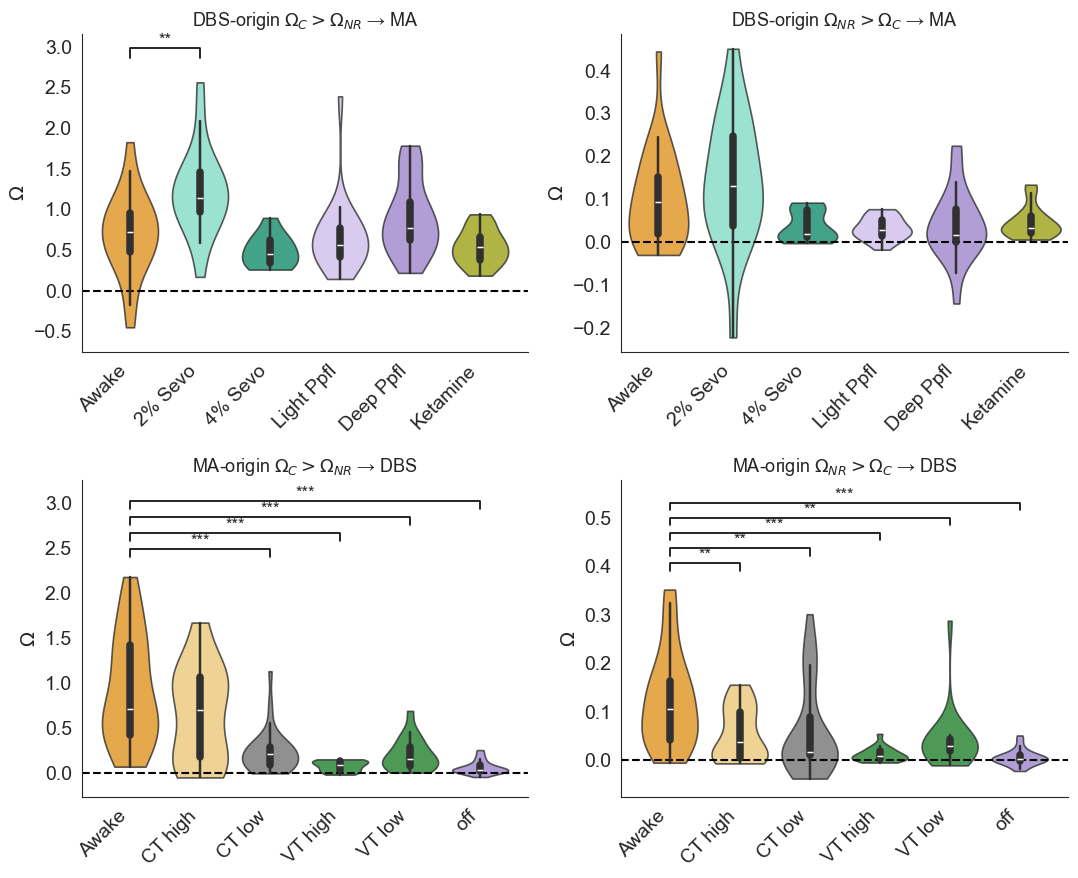

In [46]:
# 4 panels: 2 rows (DBS-origin top, MA-origin bottom) × 2 cols (nr_gt_c left, c_gt_nr right)
panel_specs = [
    {"src": "DBS", "polarity": "c_gt_nr", "tgt": "MA"},
    {"src": "DBS", "polarity": "nr_gt_c", "tgt": "MA"},
    {"src": "MA",  "polarity": "c_gt_nr", "tgt": "DBS"},
    {"src": "MA",  "polarity": "nr_gt_c", "tgt": "DBS"},
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
sns.set_style("white")

for ax, spec in zip(axes.ravel(), panel_specs):
    src, polarity, tgt = spec["src"], spec["polarity"], spec["tgt"]
    nplet  = optimal_nplets[(src, polarity)]
    print(nplet, src, polarity, tgt)
    states = custom_order[tgt]
    base   = f"{tgt}_awake"

    # compute Ω on target dataset, all states
    records = []
    for state in states:
        if state not in all_covs[tgt]:
            continue
        cov_t    = torch.as_tensor(all_covs[tgt][state])
        measures = nplets_measures(cov_t, nplets=[nplet], covmat_precomputed=True)
        for subj in range(measures.shape[1]):
            records.append({"state": state, "O": measures[0, subj, 2].item()})

    df   = pd.DataFrame(records)
    order_present = [s for s in states if s in df["state"].values]
    pal  = {s: state_colors[s] for s in order_present}

    sns.violinplot(
        data=df, x="state", y="O", hue="state", legend=False,
        inner="box", palette=pal, dodge=False, alpha=0.8, cut=0,
        order=order_present, linewidth=1.2, ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", zorder=1)
    ax.set_xticklabels(
        [pretty_labels[s] for s in order_present], rotation=45, ha="right"
    )
    ax.set_xlabel("")
    ax.set_ylabel(r"$\Omega$")
    pol_label = (r"$\Omega_C > \Omega_{NR}$" if polarity == "c_gt_nr"
                 else r"$\Omega_{NR} > \Omega_C$")
    ax.set_title(f"{src}-origin {pol_label} → {tgt}", fontsize=FONTSIZE - 1)
    sns.despine(ax=ax)

    # significance brackets (awake baseline)
    if base in df["state"].values:
        p_raw = {s: mannwhitneyu(
                    df.loc[df["state"] == base, "O"].values,
                    df.loc[df["state"] == s, "O"].values,
                    alternative="two-sided"
                )[1]
                 for s in order_present if s != base
                 and df.loc[df["state"] == s].shape[0] > 0}
        p_adj = bonferroni(p_raw)
        pos   = {s: i for i, s in enumerate(order_present)}
        y_max = df["O"].max()
        y_min = df["O"].min()
        margin = 0.10 * (y_max - y_min)
        step   = 0.08 * (y_max - y_min)
        level  = 0
        for s, p in p_adj.items():
            stars = p_to_stars(p)
            if stars == "ns":
                continue
            y = y_max + margin + level * step
            add_sig_bracket(ax, pos[base], pos[s], y, 0.5 * step, stars)
            level += 1
        if level:
            ax.set_ylim(bottom=y_min - margin, top=y_max + margin + level * step * 1.2)

plt.tight_layout()
plt.savefig(f"{results_path}/fig4_cross_dataset_violins.pdf", bbox_inches="tight")
plt.show()


---
## Summary: Table 1

Print a LaTeX-ready version of the cross-dataset PR-AUC table.

In [39]:
table = prauc_df[[
    "src_dataset", "polarity_label", "n",
    "within_PR_AUC", "cross_PR_AUC",
    "within_PR_AUC_inv", "cross_PR_AUC_inv",
]].rename(columns={
    "src_dataset":       "Source",
    "polarity_label":    "Polarity",
    "n":                 "Order",
    "within_PR_AUC":     "Within PR-AUC",
    "cross_PR_AUC":      "Cross PR-AUC",
    "within_PR_AUC_inv": "Within PR-AUC (inv)",
    "cross_PR_AUC_inv":  "Cross PR-AUC (inv)",
})
display(table)
print(table.to_latex(index=False))


,Source,Polarity,Order,Within PR-AUC,Cross PR-AUC,Within PR-AUC (inv),Cross PR-AUC (inv)
0,MA,$\Omega_C > \Omega_{NR}$,7,0.997,0.915,0.113,0.342
1,MA,$\Omega_{NR} > \Omega_C$,4,0.113,0.832,0.972,0.342
2,DBS,$\Omega_C > \Omega_{NR}$,9,0.970,0.212,0.305,0.310
3,DBS,$\Omega_{NR} > \Omega_C$,3,0.506,0.312,0.725,0.203


\begin{tabular}{llrrrrr}
\toprule
Source & Polarity & Order & Within PR-AUC & Cross PR-AUC & Within PR-AUC (inv) & Cross PR-AUC (inv) \\
\midrule
MA & $\Omega_C > \Omega_{NR}$ & 7 & 0.997000 & 0.915000 & 0.113000 & 0.342000 \\
MA & $\Omega_{NR} > \Omega_C$ & 4 & 0.113000 & 0.832000 & 0.972000 & 0.342000 \\
DBS & $\Omega_C > \Omega_{NR}$ & 9 & 0.970000 & 0.212000 & 0.305000 & 0.310000 \\
DBS & $\Omega_{NR} > \Omega_C$ & 3 & 0.506000 & 0.312000 & 0.725000 & 0.203000 \\
\bottomrule
\end{tabular}

